In [1]:
# Importer les bibliothèques necessaires
!pip install gdown
import gdown
import pandas as pd
import re
import gc
import os
import sys
import pandas as pd
import numpy as np
import tqdm
import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from scipy.stats import chi2_contingency
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import SVC


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
print("Dossier actuel :", os.getcwd())
print("Contenu du dossier actuel :", os.listdir('..'))

Dossier actuel : /home/onyxia/work/PROJET_STATAPP_MILLIMAN/notebook
Contenu du dossier actuel : ['Annexe', 'Analyses_descriptives', 'Génération de données synthétiques', '.gitignore', 'utils', '.git', 'notebook', 'README.md']


In [35]:
import sys
import os 
import importlib
sys.path.append("..")

# On récupère le dossier où se trouve ton notebook
dossier_notebook = os.getcwd()

# On remonte d'un cran pour atteindre le dossier racine du projet
dossier_racine = os.path.abspath(os.path.join(dossier_notebook, '..'))

if dossier_racine not in sys.path:
    sys.path.append(dossier_racine)

from utils import fonctions_utiles as fu 
importlib.reload(fu) 


<module 'utils.fonctions_utiles' from '/home/onyxia/work/PROJET_STATAPP_MILLIMAN/notebook/../utils/fonctions_utiles.py'>

In [4]:
np.random.seed(123)

In [5]:
# Charger les données
df = pd.read_csv('Fraud Detection Dataset.csv')  # changer le nom du fichier si nécessaire
print('Forme du dataset chargé :', df.shape)
print(df['Fraudulent'].value_counts())


Forme du dataset chargé : (51000, 12)
Fraudulent
0    48490
1     2510
Name: count, dtype: int64


# **Sommaire**

### Traitement des valeurs manquantes Na
1. 1ère méthode : moyenne
2. 2ème méthode : Interpolation Bayesienne

### Implémentation des modèles de classification
1. *RandomForest*
2. *Régression Logistique*
3. *SVM*
4. *LightGBM*

### Algorithme de génération de données synthétiques : SMOTE

0. Implémentation SMOTE

### Résultats **sans SMOTE**
1. Mesures d'évaluation des modèles
2. Comparaison des courbes ROC et AUC 


### Résultats **avec SMOTE**
1. Mesures d'évaluation des modèles
2. Comparaison des courbes ROC et AUC 



## **Traitement des valeurs manquantes Na**


### **1ère méthode : moyenne**

Implémentation fonction *missing_mean*

Preprocessing : 
Séparation des variables explicatives X de la variable expliquée y 

In [9]:
def separation(data):
    y=data['Fraudulent']
    X=data.drop(columns=['Fraudulent'])
    # Encodage des colonnes catégorielles
    for col in X.select_dtypes(include=['object','category']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    return X, y

In [113]:
# Encodage des colonnes catégorielles
for col in X.select_dtypes(include=['object','category']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

In [10]:
X,y = separation(df)

In [11]:
# Split du dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, 
random_state=42, stratify=y)

Remplissage des valeurs manquantes sur la base train uniquement

In [18]:
X_train, y_train = separation(fu.missing_mean(pd.concat([X_train, y_train], axis=1)))

Pourcentage de valeurs manquantes après traitement :
Transaction_ID                      0.0
User_ID                             0.0
Transaction_Amount                  0.0
Transaction_Type                    0.0
Time_of_Transaction                 0.0
Device_Used                         0.0
Location                            0.0
Previous_Fraudulent_Transactions    0.0
Account_Age                         0.0
Number_of_Transactions_Last_24H     0.0
Payment_Method                      0.0
Fraudulent                          0.0
dtype: float64


/home/onyxia/work/PROJET_STATAPP_MILLIMAN/notebook/../utils/fonctions_utiles.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '25043.493950642744' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mean_value
/home/onyxia/work/PROJET_STATAPP_MILLIMAN/notebook/../utils/fonctions_utiles.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2999.3552278820375' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_c.loc[(df_c['Fraudulent'] == fraud_value) & (df_c[col].isna()),col] = mean_value
/home/onyxia/work/PROJET_STATAPP_MILLIMAN/notebook/../utils/fonctions_utiles.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future v

### **Implémentation des modèles de classification**


### 1. *RandomForest*

### 2. *Régression Logistique*

Implémentation fonction *logistic*

### 3. *SVM*

### 4. *LightGBM*

In [19]:
!pip install lightgbm
import lightgbm as lgb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 86.0 MB/s  0:00:00

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### **Algorithme de génération de données synthétiques : SMOTE**

0. Implémentation fonction *smote*

In [20]:
!pip install imblearn 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [imblearn]1/3 [imbalanced-learn]

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### **Métriques d'évaluation des modèles et courbes ROC (et AUC)**

1. Implémentation fonction résultat métriques

2. Implémentation fonction de tracé des courbes ROC

### **Résultats sans SMOTE**

1. **Mesures** d'évaluation des modèles *(precision, accuracy, recall, specificity, f1-score)*

RandomForest

threshold avec Youden: 0.17
recall (sensitivity) avec Youden : 0.053784860557768925
precision avec Youden:0.17829457364341086
specificity avec Youden: 0.9849453495566096
f1-score avec Youden : 0.04859086491739553
Indice de Youden: 0.038730210114378535
accuracy:0.9520098039215686
recall (sensitivity) au seuil de 50% : 0.0249003984063745
precision au seuil de 50%:1.0
f1-score au seuil de 50% : 0.0826402288908111
accuracy:0.9520098039215686
AUC: 0.5155802085532895
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     19396
           1       1.00      0.02      0.05      1004

    accuracy                           0.95     20400
   macro avg       0.98      0.51      0.51     20400
weighted avg       0.95      0.95      0.93     20400



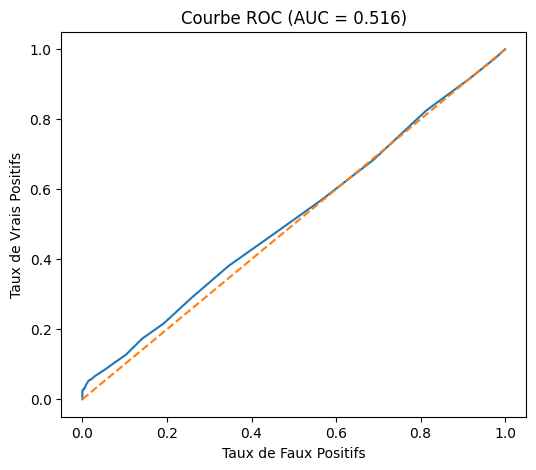

In [27]:
y_pred, y_pred_proba = fu.random_forest(X_train, y_train, X_test, y_test)
fu.metrics(y_pred, y_pred_proba,X_test, y_test,False)
fu.roc(y_pred, y_pred_proba,X_test, y_test,False)

LightGBM

[LightGBM] [Info] Number of positive: 1506, number of negative: 29094
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001554 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 30600, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049216 -> initscore=-2.961075
[LightGBM] [Info] Start training from score -2.961075
threshold avec Youden: 0.06072789575057331
recall (sensitivity) avec Youden : 0.20318725099601595
precision avec Youden:0.05935672514619883
specificity avec Youden: 0.8341410600123736
f1-score avec Youden : 0.003925417075564278
Indice de Youden: 0.037328311008389625
accuracy:0.9502450980392156
recall (sensitivity) au seuil de 50% : 0.00199203187250996
precision au seuil de 50%:0.13333333333333333
f1-score au seuil de 50% : 0.09187435939531355
accuracy:0.9502450980392156
AUC: 0.517636224538842
          

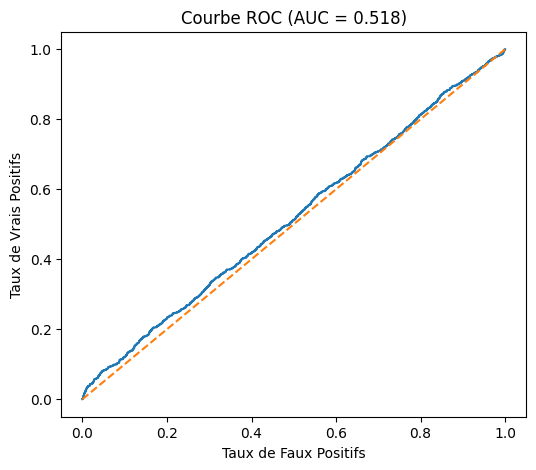

In [36]:
y_pred, y_pred_proba = fu.light_gbm(X_train, y_train, X_test, y_test)
fu.metrics(y_pred, y_pred_proba,X_test, y_test,False)
fu.roc(y_pred, y_pred_proba,X_test, y_test,False)

### **Résultats avec SMOTE**

In [37]:
## Application SMOTE à la train
X_train_s, y_train_s=fu.smote(X_train,y_train,0.2)


Après SMOTE, comptes : [29094  7273]


1. **Mesures** d'évaluation des modèles *(precision, accuracy, recall, specificity, f1-score)*

RandomForest

threshold avec Youden: 0.05
recall (sensitivity) avec Youden : 0.6812749003984063
precision avec Youden:0.05162820395877041
specificity avec Youden: 0.35429985564033817
f1-score avec Youden : 0.04669260700389105
Indice de Youden: 0.03557475603874449
accuracy:0.9519607843137254
recall (sensitivity) au seuil de 50% : 0.02390438247011952
precision au seuil de 50%:1.0
f1-score au seuil de 50% : 0.09598267301817438
accuracy:0.9519607843137254
AUC: 0.5212604675133247
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     19396
           1       1.00      0.02      0.05      1004

    accuracy                           0.95     20400
   macro avg       0.98      0.51      0.51     20400
weighted avg       0.95      0.95      0.93     20400



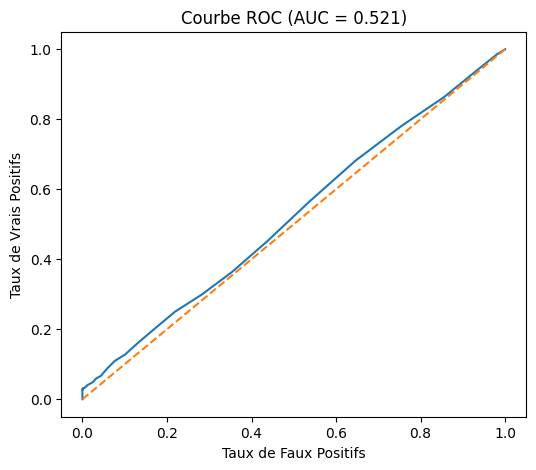

In [38]:
y_pred, y_pred_proba = fu.random_forest(X_train_s, y_train_s, X_test, y_test)
fu.metrics(y_pred, y_pred_proba,X_test, y_test,False)
fu.roc(y_pred, y_pred_proba,X_test, y_test,False)

LightGBM

[LightGBM] [Info] Number of positive: 7273, number of negative: 29094
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001744 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2803
[LightGBM] [Info] Number of data points in the train set: 36367, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199989 -> initscore=-1.386363
[LightGBM] [Info] Start training from score -1.386363
threshold avec Youden: 0.05800780072744531
recall (sensitivity) avec Youden : 0.3695219123505976
precision avec Youden:0.054459817486017074
specificity avec Youden: 0.6687976902454114
f1-score avec Youden : 0.0019801980198019802
Indice de Youden: 0.03831960259600903
accuracy:0.9505882352941176
recall (sensitivity) au seuil de 50% : 0.00099601593625498
precision au seuil de 50%:0.16666666666666666
f1-score au seuil de 50% : 0.09492907117225335
accuracy:0.9505882352941176
AUC: 0.5164944983933106
        

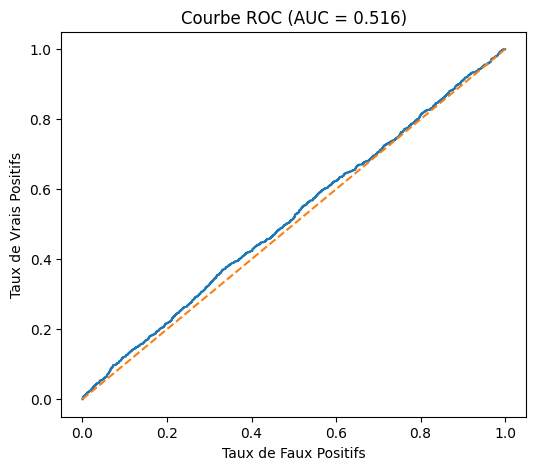

In [39]:
y_pred, y_pred_proba = fu.light_gbm(X_train_s, y_train_s, X_test, y_test)
fu.metrics(y_pred, y_pred_proba,X_test, y_test,False)
fu.roc(y_pred, y_pred_proba,X_test, y_test,False)

### **Synthèse des résultats**

Création des dataset avec missing_mean et missing_interpolation

Résultats **Sans SMOTE**

In [41]:
no_smote_col = pd.MultiIndex.from_tuples([('Sans SMOTE','Moyenne', 'recall'),('Sans SMOTE','Moyenne', 'specificity'),
                                       ('Sans SMOTE','Moyenne', 'precision'),('Sans SMOTE','Moyenne', 'f1-score'),
                                       ('Sans SMOTE','Moyenne', 'Indice de Youden'),('Sans SMOTE','Moyenne', 'seuil optimal')])



liste=[fu.random_forest,fu.light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
    L=fu.metrics(y_pred, y_pred_proba,X_test, y_test,True)
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','LightGBM'],columns=no_smote_col)

[LightGBM] [Info] Number of positive: 1506, number of negative: 29094
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000700 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 30600, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049216 -> initscore=-2.961075
[LightGBM] [Info] Start training from score -2.961075


In [42]:
df.stack(future_stack=True)

Sans SMOTE
                                 Moyenne
RandomForest recall             0.053785
             specificity        0.984945
             precision          0.178295
             f1-score           0.082640
             Indice de Youden   0.038730
             seuil optimal      0.170000
LightGBM     recall             0.203187
             specificity        0.834141
             precision          0.059357
             f1-score           0.091874
             Indice de Youden   0.037328
             seuil optimal      0.060728

Résultats **Avec SMOTE**


In [43]:
smote_col = pd.MultiIndex.from_tuples([('SMOTE','Moyenne', 'recall'),('SMOTE','Moyenne', 'specificity'),
                                       ('SMOTE','Moyenne', 'precision'),('SMOTE','Moyenne', 'f1-score'),
                                       ('SMOTE','Moyenne', 'Indice de Youden'),('SMOTE','Moyenne', 'seuil optimal')])



liste=[fu.random_forest,fu.light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test, y_test)
    L=fu.metrics(y_pred, y_pred_proba,X_test, y_test,True) 
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','LightGBM'],columns=smote_col)

[LightGBM] [Info] Number of positive: 7273, number of negative: 29094
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2803
[LightGBM] [Info] Number of data points in the train set: 36367, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199989 -> initscore=-1.386363
[LightGBM] [Info] Start training from score -1.386363


In [44]:
df.stack(future_stack=True)

SMOTE
                                Moyenne
RandomForest recall            0.681275
             specificity       0.354300
             precision         0.051628
             f1-score          0.095983
             Indice de Youden  0.035575
             seuil optimal     0.050000
LightGBM     recall            0.369522
             specificity       0.668798
             precision         0.054460
             f1-score          0.094929
             Indice de Youden  0.038320
             seuil optimal     0.058008

AUC **sans SMOTE**

In [45]:
no_smote_col = pd.MultiIndex.from_tuples([('Sans SMOTE','Moyenne', 'AUC')])

liste=[fu.random_forest,fu.light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train, y_train, X_test, y_test)
    L=fu.roc(y_pred, y_pred_proba,X_test, y_test,True) 
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','LightGBM'],columns=no_smote_col)

[LightGBM] [Info] Number of positive: 1506, number of negative: 29094
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000577 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 30600, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049216 -> initscore=-2.961075
[LightGBM] [Info] Start training from score -2.961075


In [46]:
df.stack(future_stack=True)

,,Sans SMOTE
,,Moyenne
RandomForest,AUC,0.515580
LightGBM,AUC,0.517636


AUC **avec SMOTE**

In [47]:
smote_col = pd.MultiIndex.from_tuples([('SMOTE','Moyenne', 'AUC')])

liste=[fu.random_forest,fu.light_gbm]
M=[]
for modele in liste:
    y_pred, y_pred_proba = modele(X_train_s, y_train_s, X_test, y_test)
    L=fu.roc(y_pred, y_pred_proba,X_test, y_test,True) 
    M.append(L)
df = pd.DataFrame(M,index=['RandomForest','LightGBM'],columns=smote_col)

[LightGBM] [Info] Number of positive: 7273, number of negative: 29094
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001180 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2803
[LightGBM] [Info] Number of data points in the train set: 36367, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199989 -> initscore=-1.386363
[LightGBM] [Info] Start training from score -1.386363


In [48]:
df.stack(future_stack=True)

,,SMOTE
,,Moyenne
RandomForest,AUC,0.521260
LightGBM,AUC,0.516494


### **Conclusion sur le choix du modèle :**

Au vu de l'ensemble des performances, le modèle choisi est donc le lightGBM. 

Modifions les paramètres d'entrée du classificateur afin d'améliorer les performances du modèle. 

## **Fine-Tuning du modèle choisi : lightGBM**

Pour cela nous allons utiliser la fonction *RandomizedSearchCV* du package scikit-learn.

In [38]:
from sklearn.model_selection import RandomizedSearchCV

lgbm = lgb.LGBMClassifier(learning_rate=0.09,max_depth=-5,random_state=42)
param_dist={'learning rate':[0.01,0.05,0.1,0.2],'num_leaves':[31,50,100,200,300],
             'max_depth':[-1,10,15,20],'min_child_samples':[10,20,30,50],
             'subsample':[0.6,0.8,1],'colsample_bytree':[0.6,0.8,1],
             'reg_alpha':[0,0.1,1,5],'reg_lambda':[0,0.1,1,5],
             'n_estimators':[500,1000,2000]}

search=RandomizedSearchCV(lgbm,param_distributions=param_dist,n_iter=5,cv=5,scoring='roc_auc',
                          random_state=42,n_jobs=-1,verbose=2)

search.fit(X_train_s, y_train_s)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[LightGBM] [Warning] Unknown parameter: rate
[LightGBM] [Warning] Unknown parameter: learning
[LightGBM] [Warning] Unknown parameter: rate
[LightGBM] [Warning] Unknown parameter: learning
[LightGBM] [Warning] Unknown parameter: rate
[LightGBM] [Warning] Unknown parameter: learning
[LightGBM] [Info] Number of positive: 7759, number of negative: 31033
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000717 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1805
[LightGBM] [Info] Number of data points in the train set: 38792, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200015 -> initscore=-1.386198
[LightGBM] [Info] Start training from score -1.386198
[LightGBM] [Warning] Unknown parameter: rate
[LightGBM] [Warning] Unknown parameter: learning
[LightG

,estimator,LGBMClassifie...ndom_state=42)
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning rate': [0.01, 0.05, ...], 'max_depth': [-1, 10, ...], 'min_child_samples': [10, 20, ...], ...}"
,n_iter,5
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [39]:
print(search.best_params_)

{'subsample': 0.6, 'reg_lambda': 0, 'reg_alpha': 0.1, 'num_leaves': 100, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 15, 'learning rate': 0.05, 'colsample_bytree': 1}


[LightGBM] [Info] Number of positive: 9698, number of negative: 38792
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000927 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1805
[LightGBM] [Info] Number of data points in the train set: 48490, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
threshold avec Youden: 0.07626365442977283
recall (sensitivity) avec Youden : 0.20318725099601595
precision avec Youden:0.12998712998713
specificity avec Youden: 0.9302949061662198
f1-score avec Youden : 0.15328467153284672
Indice de Youden: 0.13348215716223577
accuracy:0.9545098039215686
recall (sensitivity) au seuil de 50% : 0.08366533864541832
precision au seuil de 50%:0.9130434782608695
f1-score au seuil de 50% : 0.1585459694050294
acc

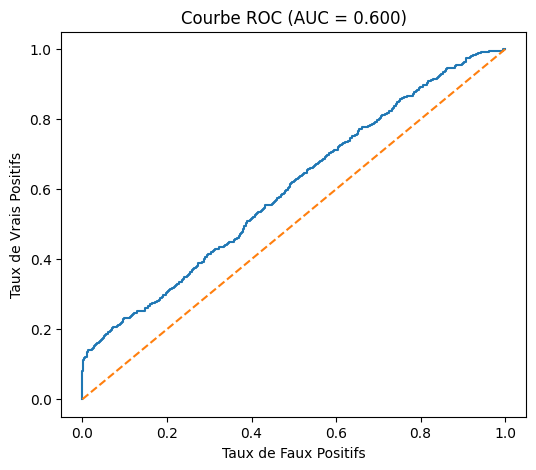

In [44]:
lg=lgb.LGBMClassifier(num_leaves=100,n_estimators=500,min_child_samples=20,max_depth=15,
                     learning_rate=0.05,colsample_bytree=1,subsample=0.6,reg_alpha=0.1,
                     reg_lambda=0)

lg.fit(X_train_s,y_train_s)

y_pred=lg.predict(X_test)
y_pred_proba=lg.predict_proba(X_test)
metrics(y_pred,y_pred_proba,X_test,y_test,False)
roc(y_pred,y_pred_proba,X_test,y_test,False)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid={'n_estimators':[500,1000,2000],'learning rate':[0.01,0.05,0.1],
           'num_leaves':[20,31,40],'max_depth':[-1,10,20]}

grid_search=GridSearchCV(estimator=lgbm,param_grid=param_grid,cv=3,scoring='roc_auc',n_jobs=-1,
verbose=1)

grid_search.fit(X_train_s,y_train_s)